<a href="https://colab.research.google.com/github/Khushba94/BDAS_iteration4/blob/main/Iteration4_BDAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install pyspark

In [3]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("CogniaWell_BDAS") \
    .getOrCreate()

spark

In [4]:
from google.colab import files

uploaded = files.upload()

Saving mental_health_lifestyle_survey_2024.csv to mental_health_lifestyle_survey_2024.csv
Saving ncpt_formatted.csv to ncpt_formatted.csv


In [5]:
ncpt_df = spark.read.csv(
    "ncpt_formatted.csv",
    header=True,
    inferSchema=True
)

life_df = spark.read.csv(
    "mental_health_lifestyle_survey_2024.csv",
    header=True,
    inferSchema=True
)

In [6]:
ncpt_df.printSchema()
life_df.printSchema()

root
 |-- user_id: integer (nullable = true)
 |-- Attention: integer (nullable = true)
 |-- MemoryRecall: integer (nullable = true)
 |-- ProcessingSpeed: integer (nullable = true)
 |-- Reasoning: double (nullable = true)
 |-- WorkingMemory: integer (nullable = true)
 |-- education_level: integer (nullable = true)
 |-- country: string (nullable = true)
 |-- time_of_day: integer (nullable = true)
 |-- grand_index: string (nullable = true)
 |-- gender_reclassified: string (nullable = true)
 |-- age_band_derive: string (nullable = true)
 |-- filter_$: integer (nullable = true)

root
 |-- Age: integer (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Occupation: string (nullable = true)
 |-- Daily_Screen_Time_Hours: double (nullable = true)
 |-- Sleep_Hours_Per_Night: double (nullable = true)
 |-- Exercise_Frequency: string (nullable = true)
 |-- Social_Interactions_Per_Week: integer (nullable = true)
 |-- Self_Reported_Stress_Level: integer (nullable = true)
 |-- Meditation_Prac

In [7]:
print(
    "NCPT Rows:",
    ncpt_df.count()
)

print(
    "Lifestyle Rows:",
    life_df.count()
)

NCPT Rows: 66341
Lifestyle Rows: 500


In [8]:
ncpt_df.show(5)
life_df.show(5)

+-------+---------+------------+---------------+---------+-------------+---------------+-------+-----------+-----------+-------------------+---------------+--------+
|user_id|Attention|MemoryRecall|ProcessingSpeed|Reasoning|WorkingMemory|education_level|country|time_of_day|grand_index|gender_reclassified|age_band_derive|filter_$|
+-------+---------+------------+---------------+---------+-------------+---------------+-------+-----------+-----------+-------------------+---------------+--------+
|1003677|       15|           6|              4|    238.0|            8|              4|     US|         11|     90.991|             Female|            61+|       1|
|1004873|       17|          10|              4|    306.0|            7|              3|     CA|         20|     85.873|             Female|            61+|       1|
|1005304|       18|           7|              7|    232.0|            8|              6|     US|         21|    117.583|             Female|          46-60|       1|
|100

In [9]:
ncpt_df.describe().show()
life_df.describe().show()

+-------+--------------------+-----------------+-----------------+------------------+------------------+-----------------+------------------+-------+------------------+------------------+-------------------+---------------+--------+
|summary|             user_id|        Attention|     MemoryRecall|   ProcessingSpeed|         Reasoning|    WorkingMemory|   education_level|country|       time_of_day|       grand_index|gender_reclassified|age_band_derive|filter_$|
+-------+--------------------+-----------------+-----------------+------------------+------------------+-----------------+------------------+-------+------------------+------------------+-------------------+---------------+--------+
|  count|               66341|            66341|            66341|             66341|             66341|            66341|             66341|  66341|             66341|             66341|              66341|          66341|   66341|
|   mean|3.8473513377956316E7|14.99463378604483|8.294810147570884| 5

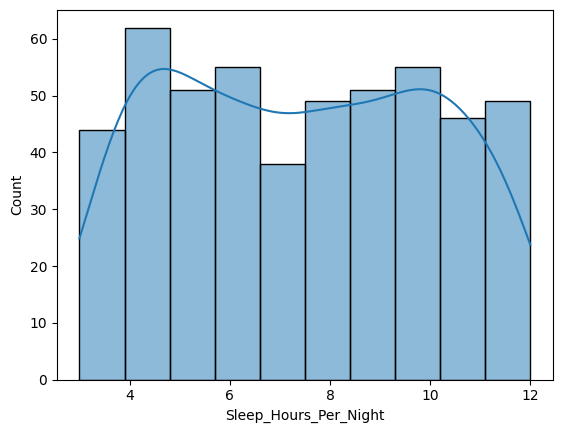

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

life_pd = life_df.toPandas()

sns.histplot(
    life_pd["Sleep_Hours_Per_Night"],
    kde=True
)

plt.show()

In [11]:
from pyspark.sql.functions import *

life_df.select(
[
count(
when(col(c).isNull(), c)
).alias(c)
for c in life_df.columns
]
).show()

+---+------+----------+-----------------------+---------------------+------------------+----------------------------+--------------------------+-------------------+---------------------+------------+---------------------+
|Age|Gender|Occupation|Daily_Screen_Time_Hours|Sleep_Hours_Per_Night|Exercise_Frequency|Social_Interactions_Per_Week|Self_Reported_Stress_Level|Meditation_Practice|Caffeine_Intake_Daily|BMI_Category|Has_Chronic_Condition|
+---+------+----------+-----------------------+---------------------+------------------+----------------------------+--------------------------+-------------------+---------------------+------------+---------------------+
|  0|     0|         0|                      0|                    0|                 0|                           0|                         0|                  0|                    0|           0|                    0|
+---+------+----------+-----------------------+---------------------+------------------+------------------------